# 2.데이터분석_이변량분석(숫자vs숫자)

## 2.1.환경준비

### **2.1.1. 라이브러리 불러오기**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **2.1.2. 데이터 불러오기**

- 타이타닉 생존자 : 'titanic_train.csv'

- 뉴욕 공기 오염도 : 'airquality2.csv'




In [5]:
# 타이타닉 데이터
titanic = pd.read_csv('data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
air = pd.read_csv('data/airquality2.csv')
air['Date'] = pd.to_datetime(air['Date'])
air.head()

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


In [8]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Ozone    153 non-null    int64         
 1   Solar.R  146 non-null    float64       
 2   Wind     153 non-null    float64       
 3   Temp     153 non-null    int64         
 4   Date     153 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2)
memory usage: 6.1 KB


----

## 2.2.시각화

**[상관 분석]**

- 상관 분석은 연속형 변수 X에 대한 연속형 변수 Y의 관계를 분석할 때 사용된다.

- Scatter를 통해 시각화 한다.



- 가설 : 온도(x)가 상승하면 아이스크림 판매량(y)이 증가할까?

    - 어떤 관계가 보이나요?

    - 얼마나 강한 관계인가요?

- 숫자 vs 숫자를 비교할 때 중요한 관점이 **‘직선’ (Linearity)** 이다.

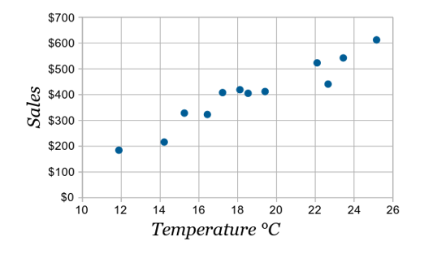

### 2.2.1 산점도

- 기본 문법
    - `plt.scatter( x축 값, y축 값 )`
    - `plt.scatter( 'x변수', 'y변수', data = dataframe이름)`

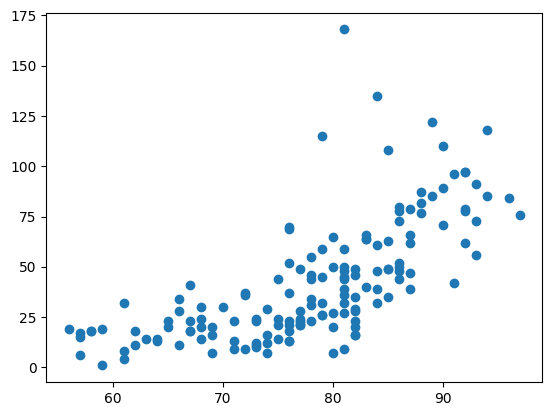

In [9]:
plt.scatter(air['Temp'], air['Ozone'])
plt.show()

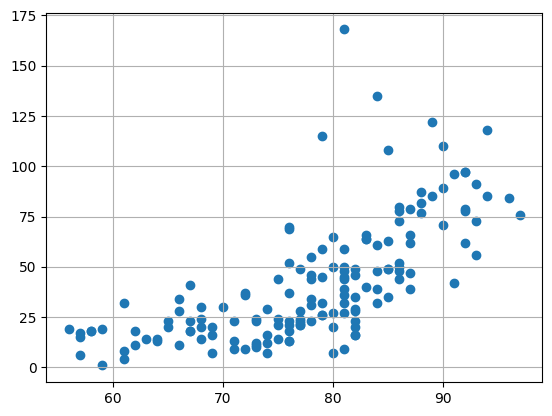

In [10]:
plt.scatter(x='Temp', y='Ozone', data=air)
plt.grid()
plt.show()

- 그래프를 그렸으면, 그래프로부터 정보를 파악해야 합니다.  

- 무엇이 보이나요?

- 온도와 오존 농도의 양의 상관 관계

**<연습문제>**

[문1] Temp, Wind, Solar.R 과 Ozone 과의 관계를 시각화 해 봅시다.

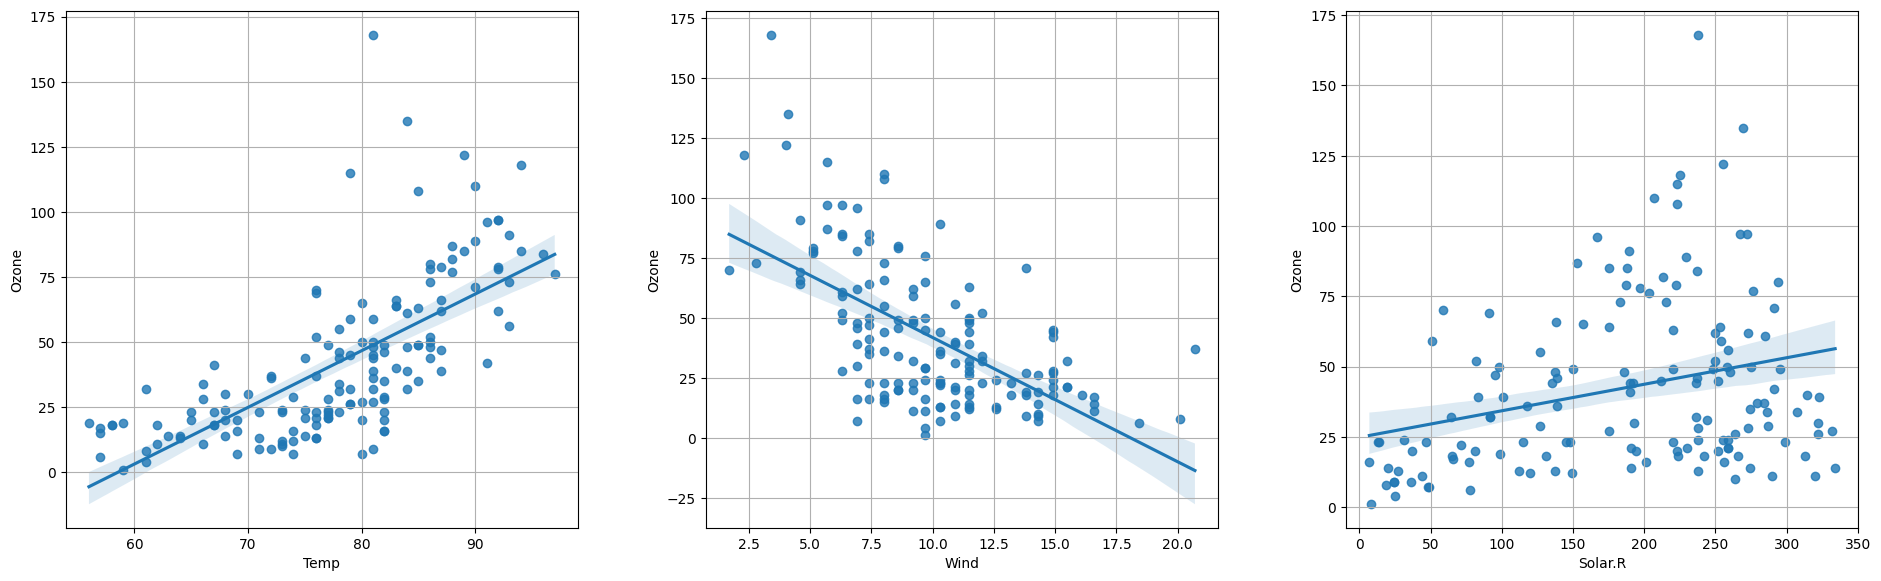

In [11]:
plt.figure(figsize=(20,7))
plt.subplot(1,3,1)
# sns.scatterplot(x='Temp', y='Ozone', data=air)
sns.regplot(x='Temp', y='Ozone', data=air)
plt.grid()

plt.subplot(1,3,2)
sns.regplot(x='Wind', y='Ozone', data=air)
plt.grid()

plt.subplot(1,3,3)
sns.regplot(x='Solar.R', y='Ozone', data=air)
plt.grid()

plt.tight_layout(pad=5)
plt.show()

[문2] Ozone과 가장 강한 관계의 x변수는?

In [12]:
# Temp

- 두 변수의 관계
    - 산점도에서 또렷한 패턴이 보인다면, 강한 관계로 볼 수 있다.
    - 특히, 직선의 패턴이 보인다면 강한 상관 관계를 나타낸다.
    - r 값은 상관 계수로 두 변수 간의 관계를 수치로 표현한 것이다.

- 상관 관계의 오해 주의하기
    - 상관 관계랑 인과관계는 같은게 아닙니다.
    - 두 변수가 관련이 있다고 해서 하나가 다른 하나를 '원인'으로 만들었다고 단정할 수 없음.
    - 예시 : 아이스크림 판매량과 익사사고 - 둘 다 여름철에 증가하지만 서로 직접적인 원인과 결과는 아님!!

<img src='https://cqeacademy.com/wp-content/uploads/2018/06/Scatter-Plots-and-Correlation-Examples.png' width=800/>

### 2.2.2 pairplot

- pairplot으로 한꺼번에 시각화 할 수 있다.
- 숫자형 변수들에 대한 산점도를 한꺼번에 그려준다.
- 그러나 변수와 데이터가 많다면, **시간이 많이** 걸리고, 일일이 확인하기 쉽지 않다.

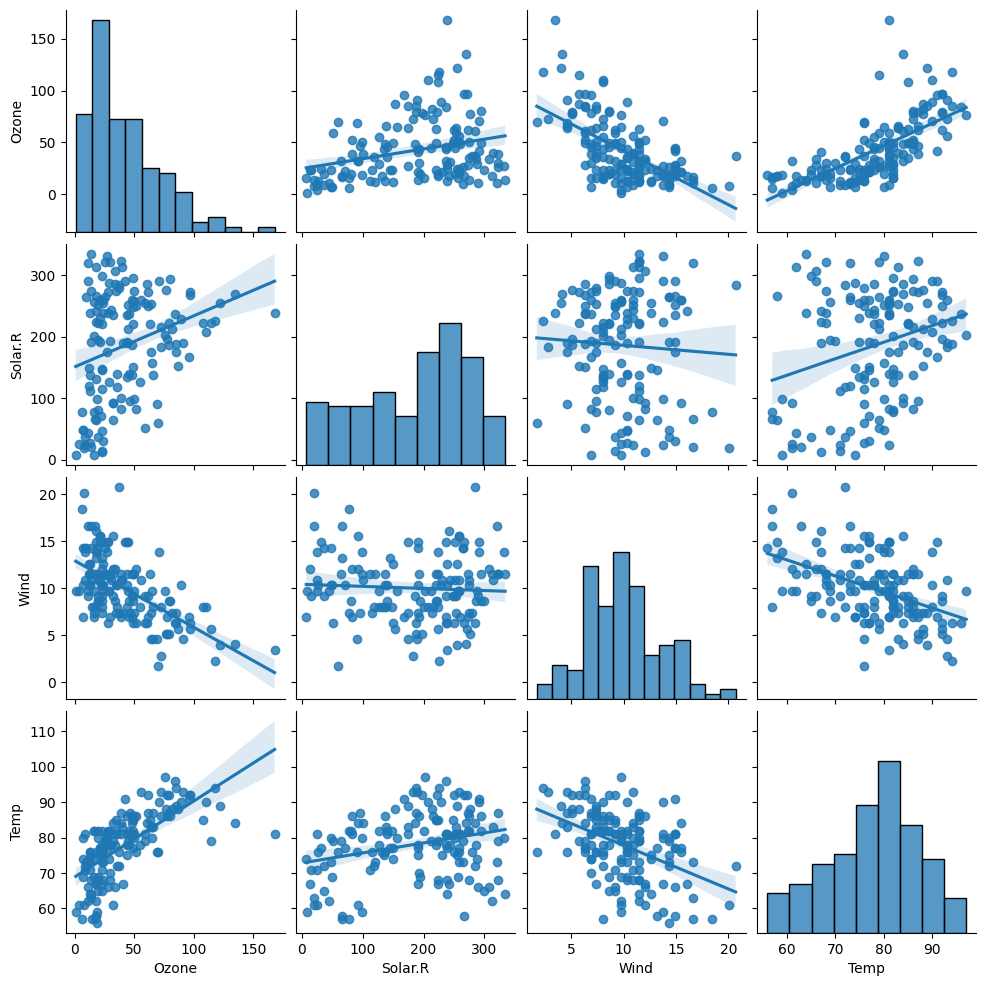

In [13]:
sns.pairplot(air, kind='reg')
plt.show()

###  2.2.3. jointplot

- jointplot은 산점도와 각각의 히스토그램을 함께 보여준다.

* Temp --> Ozone

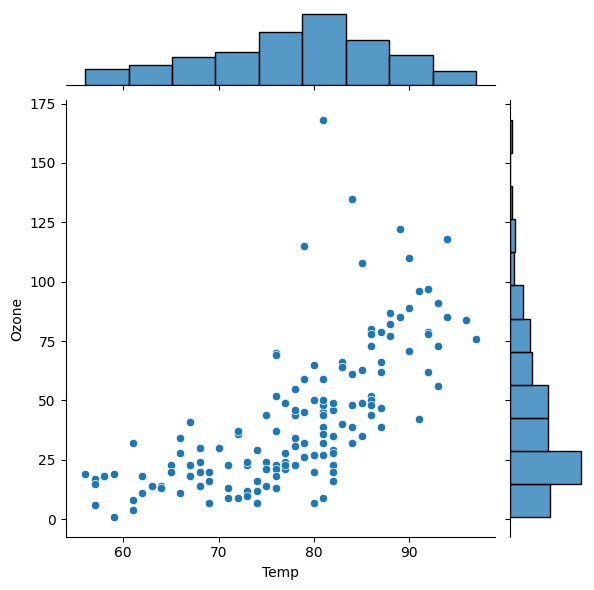

In [14]:
sns.jointplot(x='Temp', y='Ozone', data=air)
plt.show()

* Wind --> Ozone

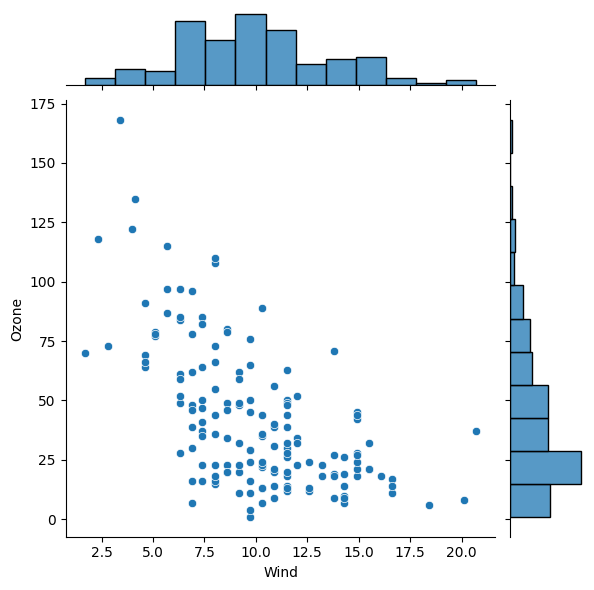

In [15]:
sns.jointplot(x='Wind', y='Ozone', data=air)
plt.show()

* Solar.R --> Ozone

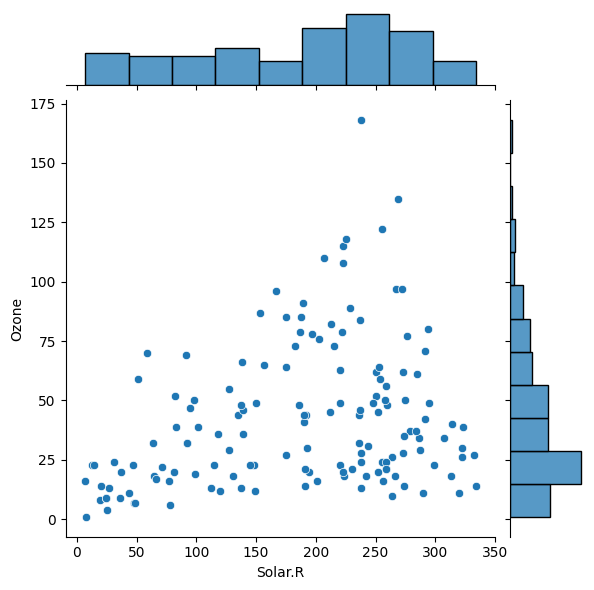

In [16]:
sns.jointplot(x='Solar.R', y='Ozone', data=air)
plt.show()

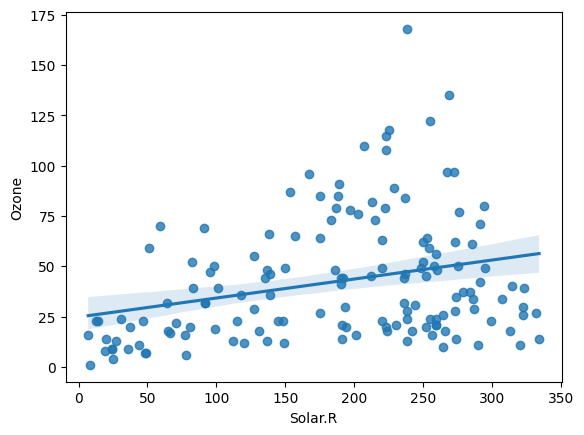

In [17]:
# 회귀선
# reg : regression
sns.regplot(x='Solar.R', y='Ozone', data=air)
plt.show()

## 2.3.수치화

- 눈으로 그래프를 살펴보며 관계를 파악하는 것은 쉽지 않다.(확실한 직선이 보이지 않는다면!)
- 관계를 숫자로 계산해서 비교
    - 관계를 수치화 -> **상관계수(correlation coefficient)**
    - 상관계수가 유의미한 지를 검정(test) -> **상관분석**

### 2.3.1. 상관계수, p-value

In [18]:
# 통계 및 확률 분포와 관련된 다양한 기능을 제공하는 모듈
import scipy.stats as spst

* 상관계수 𝑟
    * 공분산을 표준화 한 값
    * -1 ~ 1 사이의 값
    * -1, 1에 가까울 수록 강한 상관관계를 나타냄.

* 경험에 의한 대략의 기준(절대적인 기준이 절대 아니다.)
    * 강한 : 0.5 < |𝑟| ≤ 1
    * 중간 : 0.2 < |𝑟| ≤ 0.5
    * 약한 : 0.1 < |𝑟| ≤ 0.2
    * (거의)없음 : |𝑟| ≤ 0.1
    

[상관계수 공식]

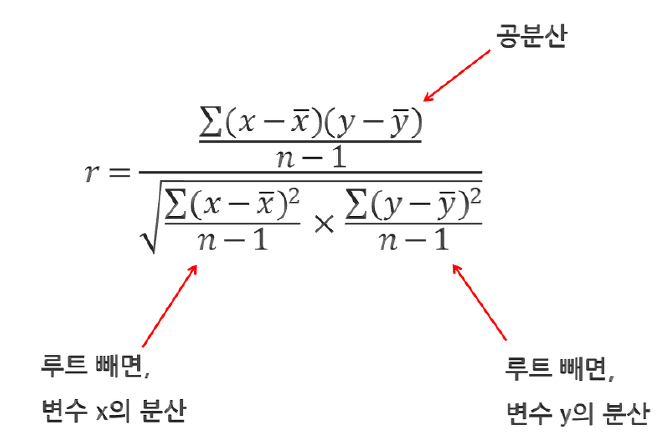

- p-value (유의확률): 두 변수 간의 상관관계가 우연에 의해 발생했을 확률을 의미함
- 판단 기준(유의수준)
    - p-value < 0.05: 통계적으로 유의미한 상관관계 -> 상관계수가 의미가 있다.
    - p-value ≥ 0.05: 유의미하지 않음 (즉, 우연에 의한 상관일 가능성이 높음) -> 상관계수가 의미가 없다.


- 상관계수와 p-value를 한 마디로 정리하자면:
    - 상관계수(r) : 두 변수의 관계 강도 측정
    - p-value : 그 관계가 우연이 아닐 확률 확인

In [ ]:
# 상관계수와 p-value
spst.pearsonr(air['Temp'], air['Ozone'])

# 결과 해석
'''
상관 계수 : 0.683 -> 두 변수는 약간 강한 양의 상관관계를 가짐. 

p-value : 2.19e-22(매우 작음)
-> p-value가 0.05보다 훨씬 작기 때문에. 귀무가설을 기각할 수 있음.
-> 두 변수(온도와 오존 농도) 간의 상관관계는 통계적으로 유의미하다.
'''

PearsonRResult(statistic=np.float64(0.6833717861490115), pvalue=np.float64(2.19776980020031e-22))

[결과]

- 튜플로 나온다.
- 튜플의 첫 번째 값 : 상관계수
- 튜플의 두 번째 값 : p-value
    - 귀무가설 : 상관 관계가 없다.(상관계수가 0이다.)
    - 대립가설 : 상관 관계가 있다.(상관계수가 0이 아니다.)
- 주의 사항 : 값에 NaN이 있으면 계산되지 않는다. 반드시 .notnull()로 제외하고 수행해야 한다.

### 2.3.2 .corr()

In [21]:
# 데이터프레임으로 부터 수치형 데이터에 대한 상관계수 구하기
air.corr()

,Ozone,Solar.R,Wind,Temp,Date
Ozone,1.000000,0.280068,-0.605478,0.683372,0.170271
Solar.R,0.280068,1.000000,-0.056792,0.275840,-0.104682
Wind,-0.605478,-0.056792,1.000000,-0.457988,-0.168683
Temp,0.683372,0.275840,-0.457988,1.000000,0.385605
Date,0.170271,-0.104682,-0.168683,0.385605,1.000000


위 결과로 부터,
- 같은 변수끼리 구한 값 1은 의미 없다.
- 상관계수의 절대값이
    - 1에 가까울 수록 강한 상관관계
    - 0에 가까울 수록 약한 상관관계
- +는 양의 상관관계, -는 음의 상관관계

### 2.3.3. heatmap으로 시각화 하기

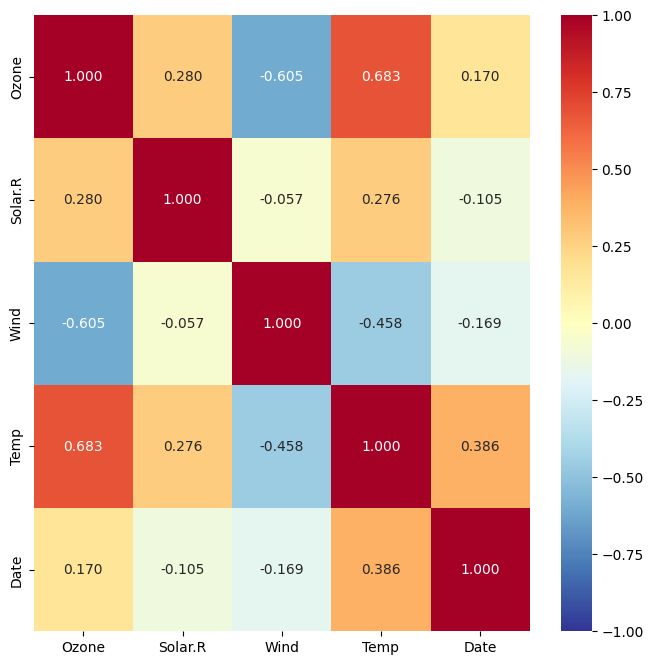

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(air.corr(),
            annot=True,         # 숫자(상관계수) 표기 여부
            fmt='.3f',          # 숫자 포멧 : 소수점 3자리까지 표기
            cmap='RdYlBu_r',    # 칼라맵
            vmin=-1, vmax=1)    # 값의 최대, 최소
plt.show()

칼라를 변경하려면 아래 링크로 가서 color map 을 확인하고 조정하세요.  
cmap(color map) : https://matplotlib.org/stable/tutorials/colors/colormaps.html

- 상관 계수의 한계
    - 상관계수는 직선의 관계(선형관계)만 수치화 해준다.
    - 직선의 기울기, 비선형 관계는 고려하지 않는다.
    - https://jumpingrivers.github.io/datasauRus/

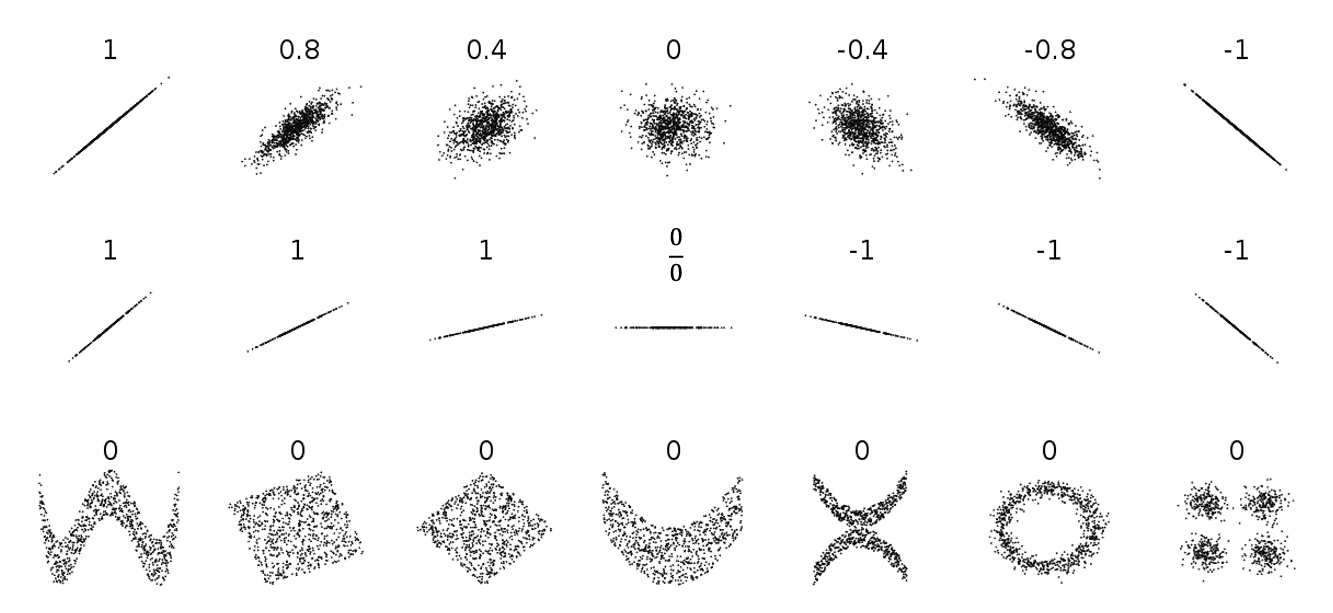

**<연습문제>**

* 다음의 변수에 대해서 상관분석을 수행하시오.

[문1] Temp --> Ozone

In [ ]:
# 상관계수, p-value
spst.pearsonr(air['Temp'], air['Ozone'])

# 상관계수 :0.683
# p-vale : 0.05보다 작다. 따라서 귀무가설을 기각할 수 있고, 상관관계는 통계적으로 유의미하다.

PearsonRResult(statistic=np.float64(0.6833717861490115), pvalue=np.float64(2.19776980020031e-22))

[문2] Wind --> Ozone

In [24]:
spst.pearsonr(air['Wind'], air['Ozone'])

PearsonRResult(statistic=np.float64(-0.6054782354684076), pvalue=np.float64(1.1255146087638106e-16))

[문3] Solar.R --> Ozone
- 단, Solar.R 에는 NaN이 있다. NaN을 제외(.notnull())하고, 상관분석을 수행하시오.

In [25]:
temp = air.loc[air['Solar.R'].notnull()]

In [26]:
spst.pearsonr(temp['Solar.R'], temp['Ozone'])

PearsonRResult(statistic=np.float64(0.2800681334905376), pvalue=np.float64(0.0006175878788566515))

## 2.4.종합 연습문제

- 보스톤 집값 데이터를 이용하여 다음 문제를 풀어보자

**변수설명**
> * medv  : 1978 보스턴 주택 가격, 506개 타운의 주택 가격 중앙값 (단위 1,000 달러) <== Target
* crim	범죄율
* zn	25,000 평방피트를 초과 거주지역 비율
* indus	비소매상업지역 면적 비율
* chas	찰스강변 위치(범주 : 강변1, 아니면 0)
* nox	일산화질소 농도
* rm	주택당 방 수
* age	1940년 이전에 건축된 주택의 비율
* dis	직업센터의 거리
* rad	방사형 고속도로까지의 거리
* tax	재산세율
* ptratio	학생/교사 비율
* lstat	인구 중 하위 계층 비율


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst

In [28]:
df = pd.read_csv('data/boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


1) crim(범죄율) --> medv(집값) 에 대해 시각화와 수치화(상관분석)을 수행후 관계를 평가하시오.

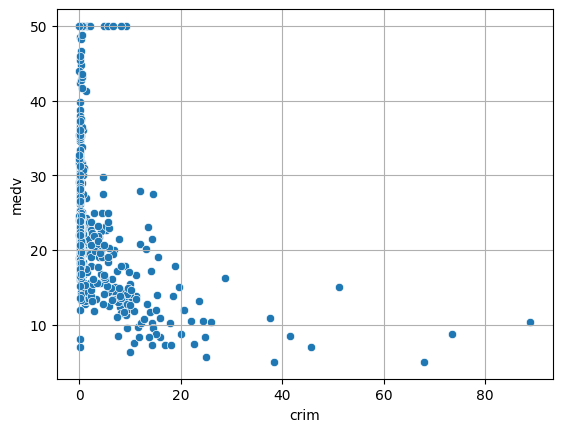

In [29]:
sns.scatterplot(x='crim', y='medv', data=df)
plt.grid()
plt.show()

In [30]:
spst.pearsonr(df['crim'], df['medv'])

PearsonRResult(statistic=np.float64(-0.3883046085868116), pvalue=np.float64(1.1739870821943559e-19))

In [ ]:
# 음의 상관관계를 갖고 있다. 

2) tax(재산세율) --> medv(집값) 에 대해 시각화와 수치화(상관분석)을 수행후 관계를 평가하시오.

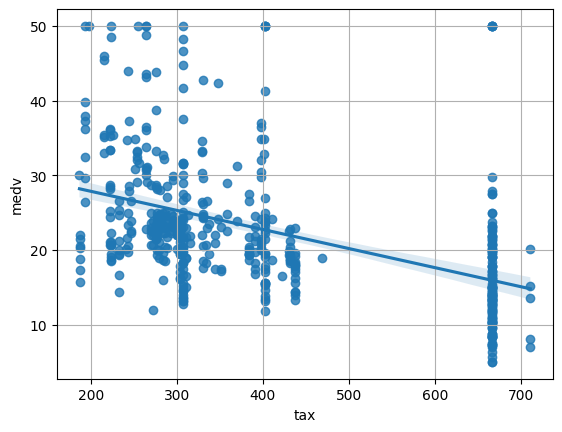

In [31]:
sns.regplot(x=df['tax'], y=df['medv'])
plt.grid()
plt.show()

In [32]:
spst.pearsonr(df['tax'], df['medv'])

PearsonRResult(statistic=np.float64(-0.46853593356776707), pvalue=np.float64(5.63773362769063e-29))

In [ ]:
# 음의 상관관계를 갖고 있다.

3) lstat(하위계층비율) --> medv(집값) 에 대해 시각화와 수치화(상관분석)을 수행후 관계를 평가하시오.

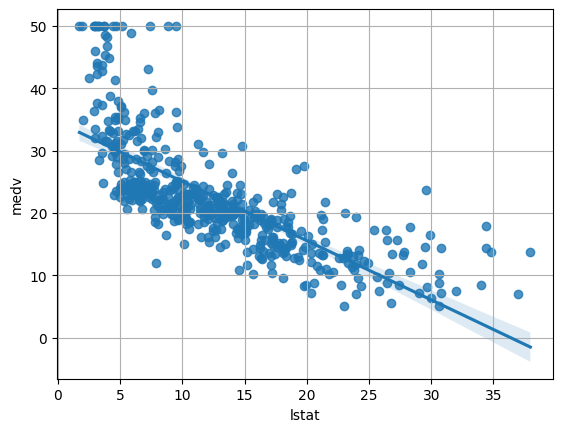

In [33]:
sns.regplot(x=df['lstat'], y=df['medv'])
plt.grid()
plt.show()

In [34]:
spst.pearsonr(df['lstat'], df['medv'])

PearsonRResult(statistic=np.float64(-0.7376627261740148), pvalue=np.float64(5.081103394387441e-88))

In [ ]:
# 강한 음의 상관관계를 갖고 있다.

4) ptratio(교사1명당 학생수) --> medv(집값) 에 대해 시각화와 수치화(상관분석)을 수행후 관계를 평가하시오.

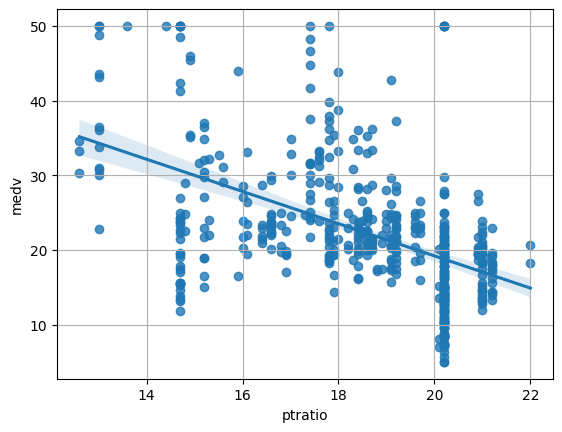

In [35]:
sns.regplot(x=df['ptratio'], y=df['medv'])
plt.grid()
plt.show()

In [36]:
spst.pearsonr(df['ptratio'], df['medv'])

PearsonRResult(statistic=np.float64(-0.5077866855375618), pvalue=np.float64(1.6095094784730858e-34))

In [ ]:
# 음의 상관관계를 갖고 있다. 

5) 전체 변수들끼리의 상관계수를 구하고, 가장 강한 상관관계와 가장 약한 상관관계를 찾아 봅시다.

In [37]:
df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


In [ ]:
# 상관계수 행렬에서 대칭 부분을 제거하고, 유효한 상관계수만 남기는 작업
temp = df.corr()

# 마스크 행렬 생성(0으로 초기화)
mask = np.zeros_like(temp)
# 상관계수 행렬과 동일한 크기의 0으로 채워진 행렬 생성

# 상삼각행렬 부분 1할당
mask[np.triu_indices_from(mask)] = True
# 상삼각행렬 부분을 1로 채움(대칭된 부분을 제외하기 위해서)

# 마스크 반전
mask = np.where(mask==1,0,1)
# 1 -> 0, 0 -> 1 (하삼각 행렬만 남김)

# 하삼각행렬만 남기고 나머지는 0처리
result = mask * temp

# 0이 아닌 값만 필터링
result = result[result != 0]

In [39]:
result


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zn,-0.200469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indus,0.406583,-0.533828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chas,-0.055892,-0.042697,0.062938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nox,0.420972,-0.516604,0.763651,0.091203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,NaN,NaN,NaN,NaN,NaN,NaN
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,NaN,NaN,NaN,NaN,NaN
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,NaN,NaN,NaN,NaN


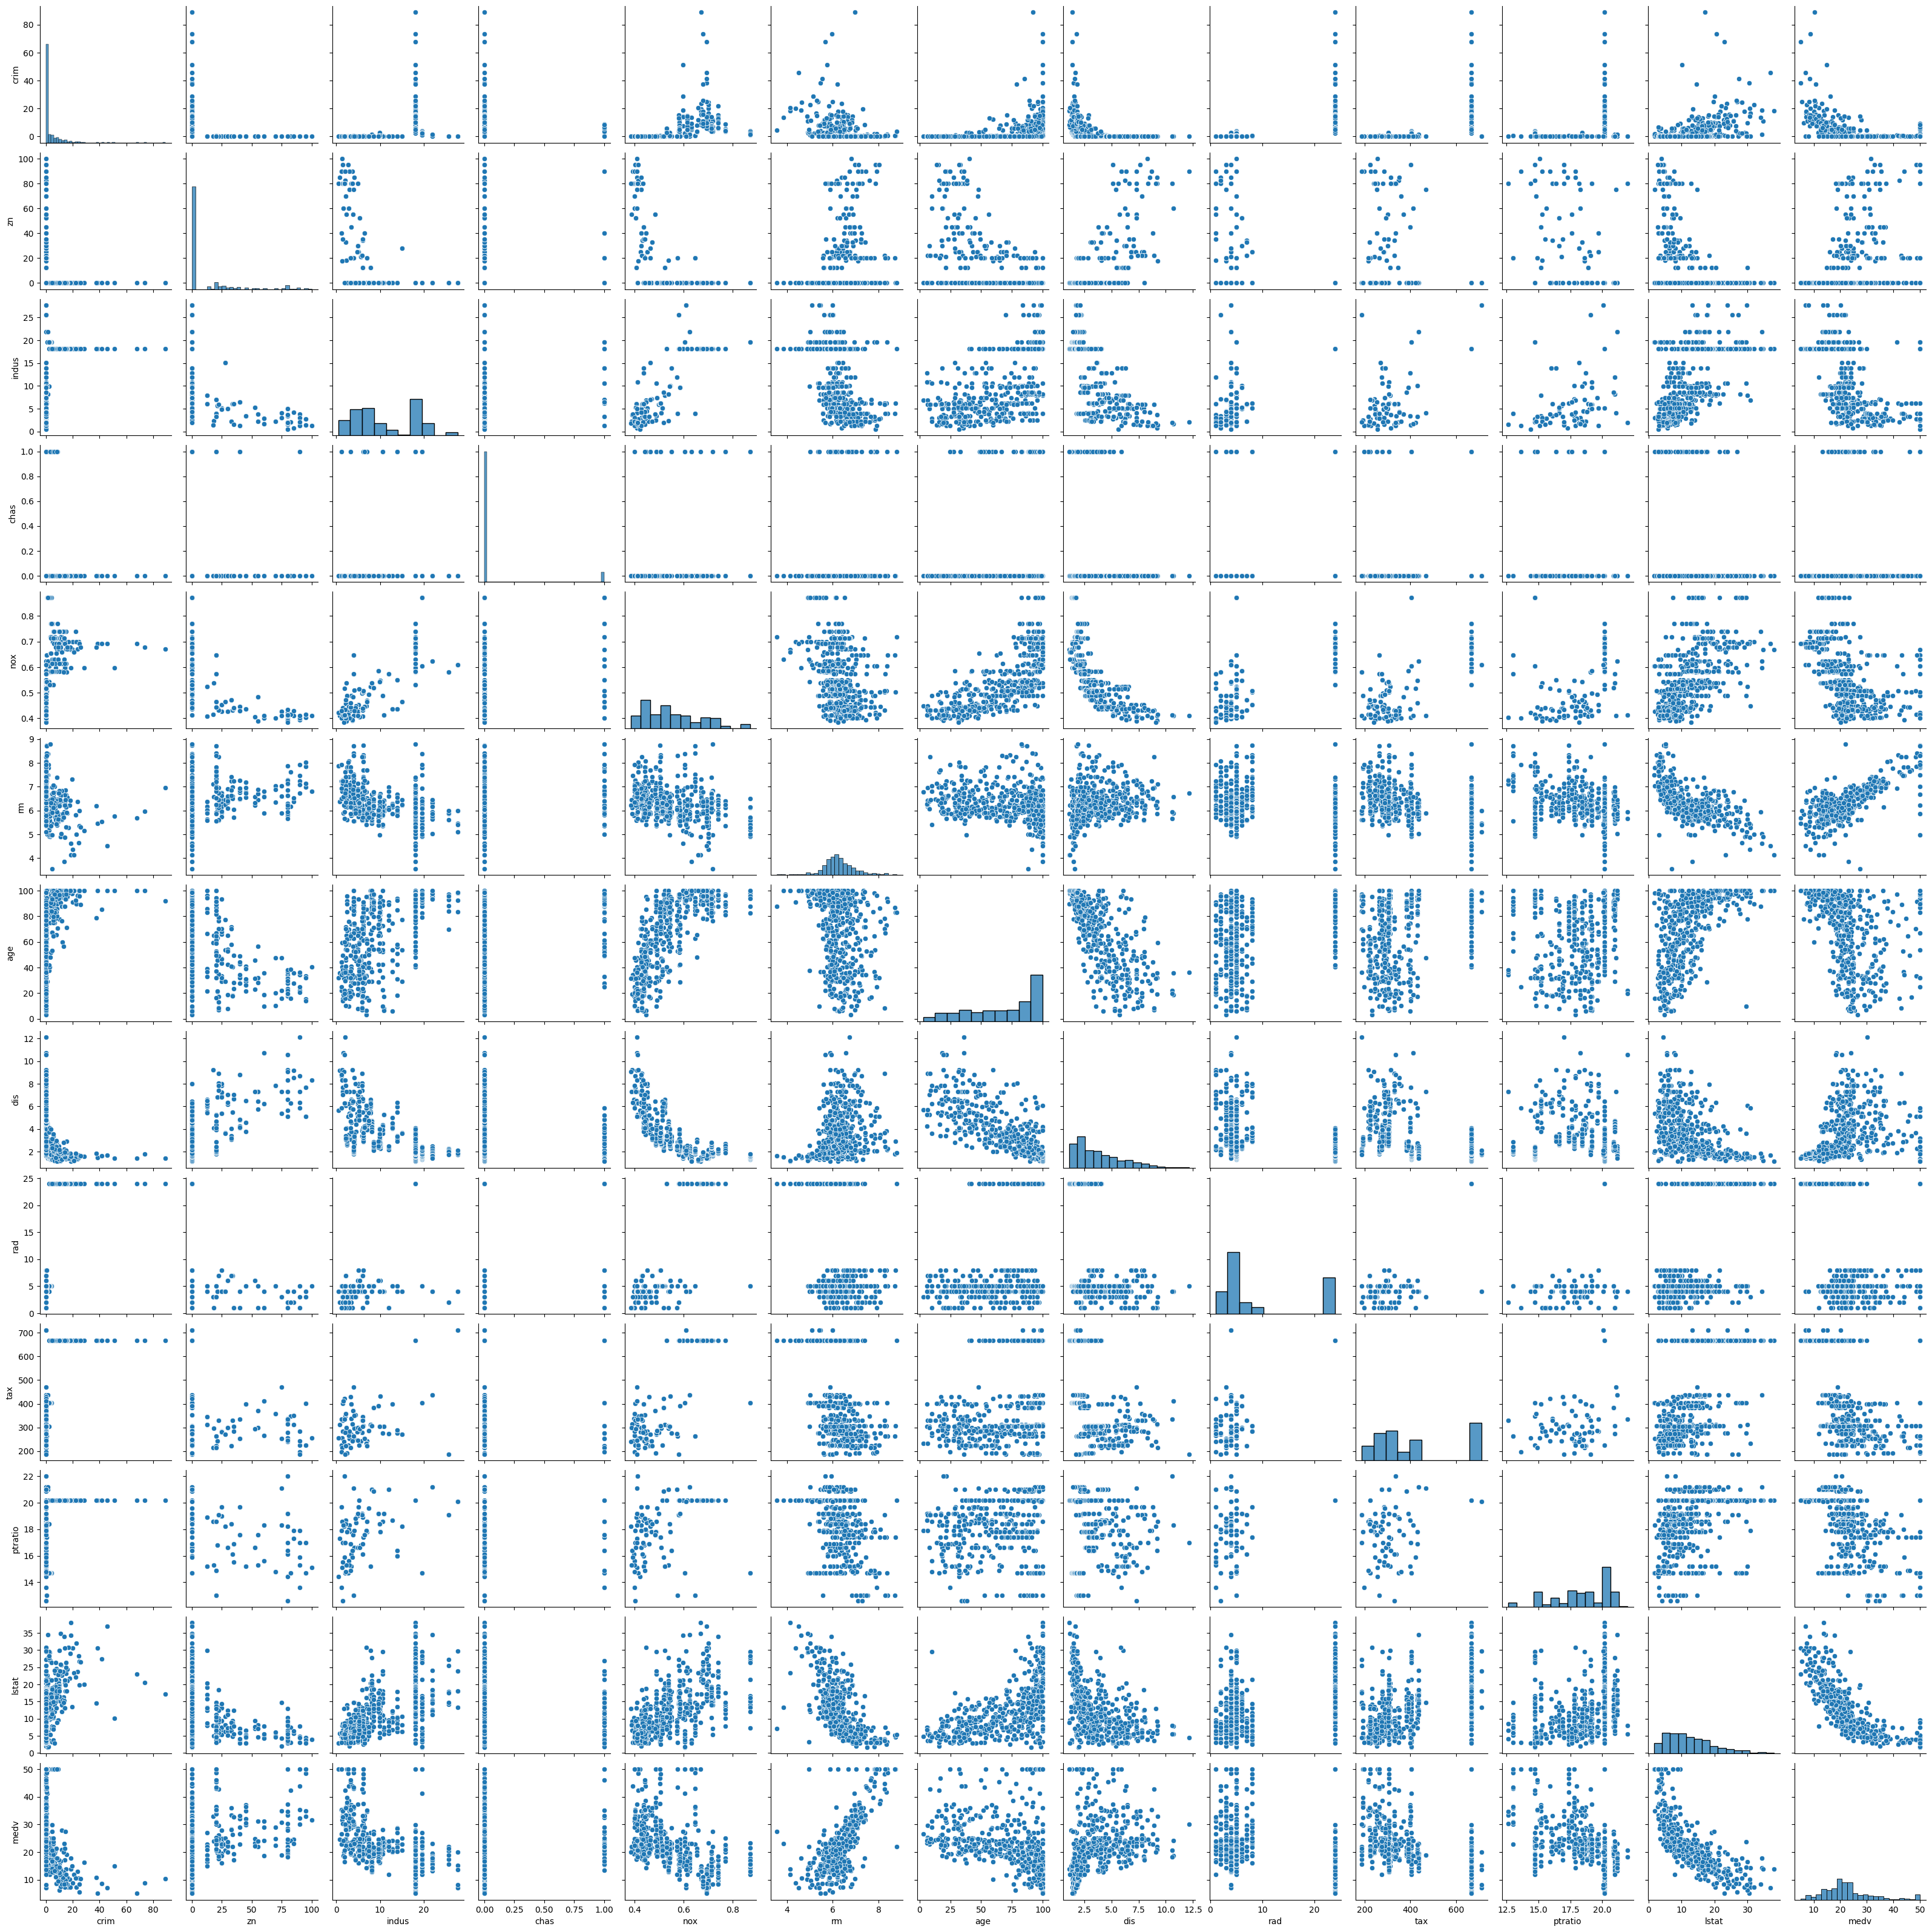

In [40]:
sns.pairplot(df)
plt.show()

1. 가장 강한 상관관계
- 변수 쌍 : tax ↔ rad
- 상관계수 : 0.910228
- 해석 : 
    - tax(재산세율)와 rad(고속도로 접근성 지수) 사이에 매우 강한 양의 상관관계가 있음.

2. 가장 약한 상관관계
- 변수 쌍 : chas ↔ rad
- 상관계수 : -0.007368
- 해석 : 
    - chas(찰스강 근처 여부)와 rad(고속도로 접근성) 사이에 거의 상관관계가 없음.


=> 이상치로 인해 상관계수가 갑자기 커지거나 작아질 수도 있다. 따라서 숫자만 보면 안 되고 반드시 산점도도 같이 봐야 합니다. 